In [1]:
import pickle

from src.protenn2.analysis.sov import get_segments

with open("../../output/protenn2/v5/data_combine.pkl", "rb") as f:
    data = pickle.load(f)

In [2]:
def segment_length(segment):
    label, start, end = segment
    return end - start

In [3]:
print(data["1d66A"])

[array([877, 877, 877, 877, 877, 877, 877, 868, 868, 868, 868, 868, 868,
       868, 868, 868, 868, 868, 868, 868, 868, 868, 868, 868, 868, 868,
       868, 868, 868, 868, 868, 868, 868, 868, 868, 868, 868, 868, 868,
       868, 868, 868, 868, 868, 868, 868, 868, 868, 868, 868, 868, 868,
       868, 868, 868, 868, 868, 868, 868, 868, 868, 868, 868, 868, 877,
       877]), array([877, 877, 877, 868, 868, 868, 868, 868, 868, 868, 868, 868, 868,
       868, 868, 868, 868, 868, 868, 868, 868, 868, 868, 868, 868, 868,
       868, 868, 868, 868, 868, 868, 868, 868, 868, 868, 868, 868, 868,
       868, 868, 868, 868, 868, 868, 868, 868, 868, 868, 868, 868, 868,
       868, 868, 868, 868, 868, 868, 868, 868, 868, 868, 868, 868, 868,
       877]), array([877, 868, 868, 868, 868, 868, 868, 868, 868, 868, 868, 868, 868,
       868, 868, 868, 868, 868, 868, 868, 868, 868, 868, 868, 868, 868,
       868, 868, 868, 868, 868, 868, 868, 868, 868, 868, 868, 868, 868,
       868, 868, 868, 868, 868, 868

In [4]:
import pandas as pd
# true_labels, pred_confidences_post, pred_confidences_two_tier
import numpy as np

rows = []
for protein_chain_id in data.keys():
    true_labels, pred_labels_post, pred_labels_two_tier = data[protein_chain_id]
    true_segments = get_segments(true_labels, 877)
    post_segments = get_segments(pred_labels_post, 877)
    two_tier_segments = get_segments(pred_labels_two_tier, 877)
    amount_true_segments = len(true_segments)
    amount_post_segments = len(post_segments)
    amount_pred_two_tier_segments = len(two_tier_segments)
    segment_lengths_true = [segment_length(segment) for segment in true_segments]
    segment_lengths_post = [segment_length(segment) for segment in post_segments]
    segment_lengths_two_tier = [segment_length(segment) for segment in two_tier_segments]

    rows.append({
        "protein_chain_id": protein_chain_id,
        "amount_true_segments": amount_true_segments,
        "amount_post_segments": amount_post_segments,
        "amount_two_tier_segments": amount_pred_two_tier_segments,
        "segment_lengths_true_mean": np.mean(segment_lengths_true),
        "segment_lengths_post_mean": np.mean(segment_lengths_post) if segment_lengths_post else 0,
        "segment_lengths_two_tier_mean": np.mean(segment_lengths_two_tier) if segment_lengths_two_tier else 0,
        "segment_lengths_true_median": np.median(segment_lengths_true) if segment_lengths_true else 0,
        "segment_lengths_post_median": np.median(segment_lengths_post) if segment_lengths_post else 0,
        "segment_lengths_two_tier_median": np.median(segment_lengths_two_tier) if segment_lengths_two_tier else 0
    })

df = pd.DataFrame(rows)



In [5]:
df.keys()

Index(['protein_chain_id', 'amount_true_segments', 'amount_post_segments',
       'amount_two_tier_segments', 'segment_lengths_true_mean',
       'segment_lengths_post_mean', 'segment_lengths_two_tier_mean',
       'segment_lengths_true_median', 'segment_lengths_post_median',
       'segment_lengths_two_tier_median'],
      dtype='object')

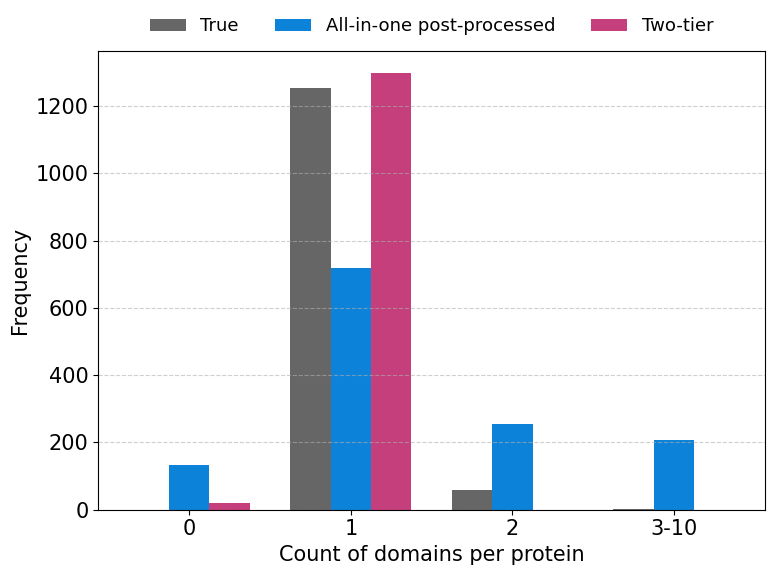

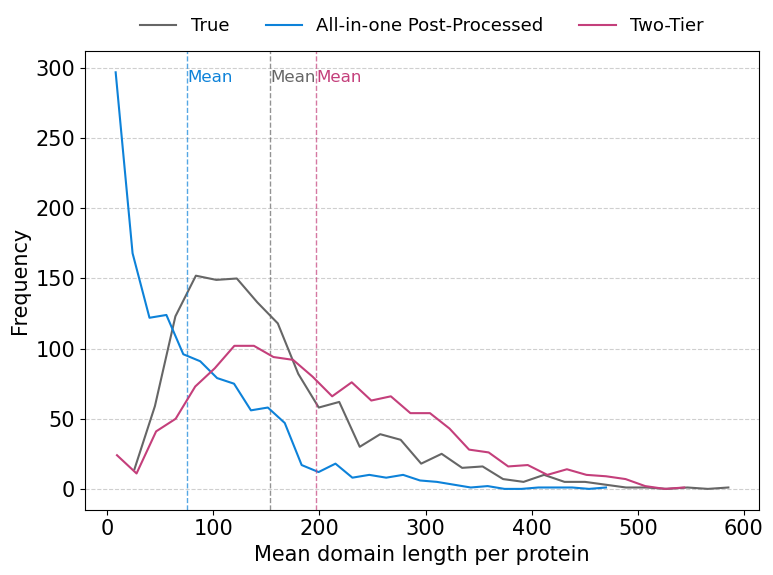

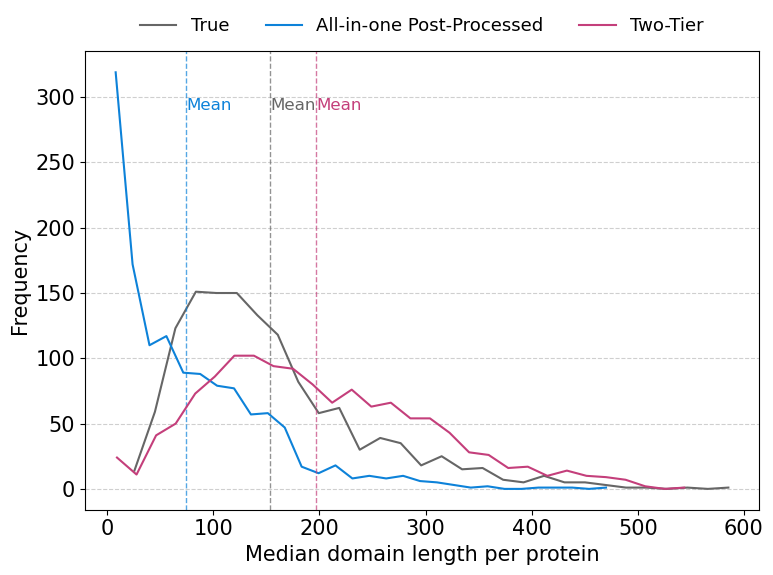

In [24]:
import matplotlib.pyplot as plt
plt.rcParams.update({'font.size': 15})

# Define your color mapping (from the original scheme)
colors = {
    'true':      '#666666',  # baseline → true labels
    'post':      '#0d82d9',  # post-processed
    'two_tier':  '#C43F7B'   # two-tier
}

# Metrics to plot: mapping of plot title → [true, post, two_tier] column names
metrics = {
    'Count of domains per protein':           ['amount_true_segments',
                                     'amount_post_segments',
                                     'amount_two_tier_segments'],
    'Mean domain length per protein':         ['segment_lengths_true_mean',
                                     'segment_lengths_post_mean',
                                     'segment_lengths_two_tier_mean'],
    'Median domain length per protein':       ['segment_lengths_true_median',
                                     'segment_lengths_post_median',
                                     'segment_lengths_two_tier_median']
}

for title, cols in metrics.items():
    plt.figure(figsize=(8, 6))

    if title.startswith('Count of domains'):
        # --- new: custom bar‐plot with ranges 0, 1, 2, 3–10 ---
        categories = ["0", "1", "2", "3-10"]
        x = np.arange(len(categories))
        width = 0.25

        for i, (model, col) in enumerate(zip(['true', 'post', 'two_tier'], cols)):
            s = df[col]
            counts = [
                (s == 0).sum(),
                (s == 1).sum(),
                (s == 2).sum(),
                ((s >= 3) & (s <= 10)).sum()
            ]
            plt.bar(x + (i - 1) * width,
                    counts,
                    width,
                    label=(
                        "True"
                        if model == 'true' else
                        "All-in-one post-processed"
                        if model == 'post' else
                        "Two-tier"
                    ),
                    color=colors[model])

        plt.xticks(x, categories)
        plt.xlabel(title)
        plt.ylabel('Frequency')

    else:
        # --- existing line‐plot of histogram counts unchanged ---
        for model, col in zip(['true', 'post', 'two_tier'], cols):
            counts, bins = np.histogram(df[col], bins=30)
            centers = 0.5 * (bins[:-1] + bins[1:])
            plt.plot(centers,
                     counts,
                     label=(
                         model.replace('_', '-').title()
                         if model != 'post'
                         else "All-in-one Post-Processed"
                     ),
                     color=colors[model])
            mean_val = df[col].mean()
            median_val = df[col].median()
            # Plot vertical lines
            plt.axvline(mean_val, color=colors[model], linestyle='--', linewidth=1, alpha=0.7)
            plt.text(mean_val, 290, f'Mean', rotation=0, color=colors[model], fontsize=12)
        plt.xlabel(title)
        plt.ylabel('Frequency')

    plt.legend(loc='lower center', bbox_to_anchor=(0.5, 1),
               ncol=4, frameon=False, fontsize=13)
    plt.grid(axis='y', linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.savefig(f"../../output/protenn2/v5/{title}.png", dpi=1000)
    plt.show()
